In [1]:
"""
Primary INP/ice crystal number concentration parameterizations from literature   
"""
__author__ = "Cuiqi Zhang"
__copyright__ = "CERTAINTY 2024-2027. This project has received funding from Horizon Europe programme under Grant " \
                "Agreement No 101137680."
__credits__ = ["Cuiqi Zhang"]
__license__ = "CC"
__version__ = "1.0.1"
__maintainer__ = "Cuiqi Zhang"
__email__ = "cuiqi.zhang@env.ethz.ch"
__status__ = "Production"

# Initializaion

In [2]:
import os
from datetime import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl


# Initialization
config = {
    "font.family": 'sans-serif',
    "font.size": 8,
    # "mathtext.fontset": 'stix',
    "mathtext.fontset": 'stixsans',
    "font.sans-serif": ['Arial'],
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'axes.unicode_minus': False
    # 'text.usetex': True
}

mpl.rcParams.update(config)


fileDateTime = dt.strftime(dt.now(), "%Y%m%d_%H%M%S_")

msDir = r"/home/jovyan/INP_ETHZ"

try:
    os.chdir(msDir)
except:
    os.mkdir(msDir)

# Water vapor pressure functions

In [3]:
# Saturation pressure of liquid water @ T
def ew(T_K):
    # Murphy & Koop 2005 eq.10, 123K < T_K < 332K and e in Pa
    # Saturation pressure of liquid water
    if np.any(T_K < 0):
        T_K = T_C_to_K(T_K)
    return np.exp(54.842763 -
                  6763.22 /
                  T_K -
                  4.210 *
                  np.log(T_K) +
                  0.000367 *
                  T_K +
                  np.tanh(0.0415 *
                          (T_K -
                           218.8)) *
                  (53.878 -
                      1331.22 /
                      T_K -
                      9.44523 *
                      np.log(T_K) +
                      0.014025 *
                      T_K))
    # ew = np.exp(54.842763 - 6763.22 / T - 4.210 * np.log(T) + 0.000367 * T + np.tanh(0.0415 * (T - 218.8)) * (
    #             53.878 - 1331.22 / T - 9.445238 * log(T) + 0.014025 * T))


# Saturation pressure of solid ice @ T
def ei(T_K):
    # Murphy and Koop 2005 eq.7, T_K > 110K in K and e in Pa
    # Saturation pressure of solid ice
    if np.any(T_K < 0):
        T_K = T_C_to_K(T_K)
    return np.exp(
        9.550426 -
        5723.265 /
        T_K +
        3.53068 *
        np.log(T_K) -
        0.00728332 *
        T_K)
       


def SS_w_to_i(T_K, SSw):
    if np.any(T_K < 0):
        T_K = T_C_to_K(T_K)
    return SSw * ew(T_K) / ei(T_K)


def SS_i_to_w(T_K, SSi):
    if np.any(T_K < 0):
        T_K = T_C_to_K(T_K)
    return SSi * ei(T_K) / ew(T_K)

# Parameterizations
## Good to go

### Fletcher 1962

In [6]:
def Fletcher1962(T):
    """
    Calculate the number concentration of ice nuclei (INP) using the Fletcher (1962) eq. 9.1 parameterization.
    
    Parameters:
    T (float): Temperature in degrees Celsius. -10 C to -30 C.
    
    Returns:
    float: Number concentration of ice nuclei (INP) per liter.
    """
    n0= 1e-5 # Reference INP concentration at 0 degrees Celsius, [#/L]
    b = 0.6
    T0 = 0  # Reference temperature in degrees Celsius
    
    N_INP = n0*np.exp(b * (T0-T))
    return N_INP

# Example usage:
T_Fletcher1962 = np.linspace(-10, -30, 7)  # Temperature in degrees Celsius
N_INP_Fletcher1962 = Fletcher1962(T_Fletcher1962)
print(f"INP concentration at {T_Fletcher1962[0]:.1f}°C: {N_INP_Fletcher1962[0]:.1e} per liter")

INP concentration at -10.0°C: 4.0e-03 per liter


### Young 1974

In [7]:
def Young1974(T, h):
    """
    Calculate the contact INP number concentration based on Meyers 1992 eq. 2.5
    
    Parameters:
    T (float): Temperature in degrees Celsius.
    
    Returns:
    float: Number concentration of ice nuclei (INP) per liter.
    """
    T0=0 # Reference temperature in degrees Celsius
    n0 = (2e2-10)*h/5000 # decrease linearly as a function of altitude, h in m

    N_INP = n0 *(270.16-(T+273.15))**1.3
    return N_INP

T_Young1974 = np.linspace(-5, -30, 7)  # Temperature in degrees Celsius
h = 1000
N_INP_Young1974 = Young1974(T_Young1974, h)
print(f"INP concentration at {T_Young1974[0]:.1f}°C {h} m: {N_INP_Young1974[0]:.1e} per liter")

INP concentration at -5.0°C 1000 m: 9.4e+01 per liter


### Cooper 1986

In [8]:
def Cooper1986(T):
    """
    Calculate the number concentration of ice nuclei (INP) using the Cooper (1986) Fig. 4.3 parameterization.
    
    Parameters:
    T (float): Temperature in degrees Celsius.
    
    Returns:
    float: Number concentration of ice nuclei (INP) per liter.
    """
    a = -2.35  # Empirical constant
    b = -0.135  # Empirical constant
    T0 = 0  # Reference temperature in degrees Celsius
    
    N_INP = 10**(a+ b*(T-T0))
    return N_INP

# Example usage:
T_Cooper1986 = np.linspace(-5, -30, 10)  # Temperature in degrees Celsius
N_INP_Cooper1986 = Cooper1986(T_Cooper1986)

### Cotton1986

In [9]:
def Cotton1986_dep(T, S_i):
    """
    Calculate the deposition INP number concentration Cotton1986 eq 50 parameterization.
    
    Parameters:
    T (float): Temperature in degrees Celsius.
    S_i (float): Supersaturation with respect to ice.
    
    Returns:
    float: Number concentration of ice nuclei (INP) per liter.
    """
    T0=0 # Reference temperature in degrees Celsius
    n0 = 1e-5
    a = 0.6
    b = 4.5
    N_INP = n0 *(((S_i - 1)/(ew(T+273.15)/ei(T+273.15)-1))**b)*(np.exp(a * (T0 - T)))
    return N_INP

T_Cotton1986_dep = np.linspace(-5, -30, 6)  # Temperature in degrees Celsius
S_i = 1.2
N_INP_Cotton1986_dep = Cotton1986_dep(T_Cotton1986_dep, S_i)
print(T_Cotton1986_dep, N_INP_Cotton1986_dep)

[ -5. -10. -15. -20. -25. -30.] [ 0.10477509  0.08277239  0.23798377  1.16301614  7.61870637 60.30950976]


In [10]:
def Cotton1986_contact(T):
    """
    Calculate the contact INP number concentration Cotton1986 eq 54 parameterization. Similar to Cotton1982 and Young1974.
    
    Parameters:
    T (float): Temperature in degrees Celsius.
    
    Returns:
    float: Number concentration of ice nuclei (INP) per liter.
    """
    T0=0 # Reference temperature in degrees Celsius
    n0 = 2e2

    N_INP = n0 *(270.16-(T+273.15))**1.3
    return N_INP

T_Cotton1986_contact = np.linspace(-5, -30, 10)  # Temperature in degrees Celsius
N_INP_Cotton1986_contact = Cotton1986_contact(T_Cotton1986_contact)
print(N_INP_Cotton1986_contact)

[  495.66113875  1531.80744403  2776.66232636  4169.5450715
  5680.56838964  7291.33080017  8989.16130686 10764.71288086
 12610.75857951 14521.51591362]


### Meyers 1992

In [11]:
def Meyers1992_dep(S_i):
    """
    Calculate the number concentration of ice nuclei (INP) using the Meyers et al. (1992) eq2.4 parameterization.
    
    Parameters:
    T (float): Temperature in degrees Celsius.
    S_i (float): Supersaturation with respect to ice.
    mode (str): Freezing mode ('deposition', 'condensation', 'immersion').
    
    Returns:
    float: Number concentration of ice nuclei (INP) per liter.
    """
    a=-0.639
    b=0.1296
    
    N_INP = np.exp(a + b* (100*(Si-1)))
    return N_INP

# Example usage:
Si = np.linspace(-5, -30, 10)  # Temperature in degrees Celsius
N_INP_Cotton1986_contact = Cotton1986_contact(T_Cotton1986_contact)
print(N_INP_Cotton1986_contact)

[  495.66113875  1531.80744403  2776.66232636  4169.5450715
  5680.56838964  7291.33080017  8989.16130686 10764.71288086
 12610.75857951 14521.51591362]


In [12]:
def Meyers1992_contact(T):
    """
    Calculate the contact INP number concentration Meyers1992 eq 2.6 parameterization.
    
    Parameters:
    T (float): Temperature in degrees Celsius.
    
    Returns:
    float: Number concentration of ice nuclei (INP) per liter.
    """
    T0=0 # Reference temperature in degrees Celsius
    a=-2.8
    b=0.262

    N_INP = np.exp(a+ b*(T0-T))
    return N_INP

T_Meyers1992_contact = np.linspace(-2, -25, 10)  # Temperature in degrees Celsius
N_INP_Meyers1992_contact = Meyers1992_contact(T_Meyers1992_contact)
print(T_Meyers1992_contact, N_INP_Meyers1992_contact)

[ -2.          -4.55555556  -7.11111111  -9.66666667 -12.22222222
 -14.77777778 -17.33333333 -19.88888889 -22.44444444 -25.        ] [ 0.10269416  0.20059959  0.39184501  0.76541789  1.49514355  2.92056701
  5.70494495 11.1438624  21.76807495 42.521082  ]


### Vignon 2021

In [17]:
def Vignon2021(T):
    """
    Calculate the INP number concentration using the Vignon et al. (2021) parameterization based on the MARCUS Antarctic campaign.
    
    Parameters:
    T (float or np.ndarray): Temperature in degrees Celsius.
    
    Returns:
    float or np.ndarray: Number concentration of ice nuclei (INP) per liter.
    """
    T0 = -4  # Reference temperature in degrees Celsius
    T1 = -21.06  # Reference temperature in degrees Celsius
    T2 = -30.35  # Reference temperature in degrees Celsius
    
    N_INP = np.zeros_like(T)
    
    # Apply the parameterization based on temperature ranges
    mask1 = (T1 < T) & (T <= T0)
    mask2 = (T2 < T) & (T <= T1)
    mask3 = T <= T2
    
    N_INP[mask1] = 10**(-0.14 * (T[mask1] - T1) - 2.88)
    N_INP[mask2] = 10**(-0.31 * (T[mask2] - T1) - 2.88)
    N_INP[mask3] = 10**0  # This is effectively 1, as a and b are 0 in this range
    
    return N_INP

# Example usage:
T_Vignon2021 = np.linspace(-5, -40, 8)  # Temperature in degrees Celsius
N_INP_Vignon2021 = Vignon2021(T_Vignon2021)
print(pd.DataFrame(T_Vignon2021, N_INP_Vignon2021))

             0
0.000007  -5.0
0.000037 -10.0
0.000187 -15.0
0.000937 -20.0
0.021948 -25.0
0.778753 -30.0
1.000000 -35.0
1.000000 -40.0


### Li 2022 Arctic

In [22]:
def Li2022(T, bound):
    """
    Calculate the Arctic INP number concentration Li 2022 eq.3 Table 1 parameterization.
    
    Parameters:
    T (float): Temperature in degrees Celsius.
    
    Returns:
    float: Number concentration of ice nuclei (INP) per stdL.
    """
    T0=0 # Reference temperature in degrees Celsius
    if bound == 'median':
        a=-0.3504 # median
        b=-10.1826 #
    elif bound == 'lower':
        a=-0.3731
        b=-12.7993
    elif bound == 'upper':
        a=-0.3278
        b=-7.5659

    N_INP = np.exp(a*(T-T0)+b)
    return N_INP

T_Li2022 = np.linspace(-2, -35, 10)  # Temperature in degrees Celsius
N_INP_Li2022_median = Li2022(T_Li2022, 'median')
N_INP_Li2022_lower = Li2022(T_Li2022, 'lower')
N_INP_Li2022_upper = Li2022(T_Li2022, 'upper')
print(T_Li2022, N_INP_Li2022_lower, N_INP_Li2022_median, N_INP_Li2022_upper)

[ -2.          -5.66666667  -9.33333333 -13.         -16.66666667
 -20.33333333 -24.         -27.66666667 -31.33333333 -35.        ] [5.82646551e-06 2.28841354e-05 8.98801597e-05 3.53015003e-04
 1.38650836e-03 5.44567625e-03 2.13885403e-02 8.40060325e-02
 3.29943671e-01 1.29589296e+00] [7.62266057e-05 2.75478768e-04 9.95565142e-04 3.59791776e-03
 1.30026773e-02 4.69909617e-02 1.69822756e-01 6.13730115e-01
 2.21798694e+00 8.01568302e+00] [9.97458514e-04 3.31808766e-03 1.10377581e-02 3.67175660e-02
 1.22142526e-01 4.06312247e-01 1.35161477e+00 4.49620332e+00
 1.49568093e+01 4.97544546e+01]


## To be finished

### Bigg 1953

In [5]:
def Bigg1953(T):
    # Bigg, E. K. (1953). The supercooling of water. Proceedings of the Physical Society. Section B, 66(5), 688.
    # T in C, e in Pa
    return 273.16 - 0.0001 * T ** 2 + 0.0001 * T ** 3

### Daily2025

In [ ]:
# From Paul Connolly @UoM
# https://github.com/UoM-maul1609/bin-microphysics-model/blob/master/python/dcmex/dcmex_inp.py
# https://essopenarchive.org/users/881532/articles/1260386/master/file/data/1018887_0_merged_1736184581/1018887_0_merged_1736184581.pdf?inline=true

if __name__=="__main__":
	print('Calculating the INP parameterisation from Daly et al')
	
	T=np.linspace(273.15,273.15-40,1000)
	
	
	NINP=np.zeros(len(T))
	Tc=T-273.15
	log_ns = -3.25 + (-0.793*Tc) + (-6.91e-2*Tc**2) + (-4.17e-3*Tc**3) + \
		(-1.05e-4*Tc**4) + (-9.08e-7*Tc**5)
	ns = (10.0**log_ns)*1e4
	
	Adust=7.5 # micrometers^2 per cm^-3
	Adust = Adust*1e6 # micrometers ^2 m^-3
	Adust = Adust/(1e12) # m^2 m^-3
	NINP1 = Adust*0.05*ns
	#NINP1[:] = 0.0
	ax=plt.plot(Tc,NINP1/1000.)
	plt.ylabel('N$_{INP}$ (L$^{-1}$)')
	plt.xlabel('T ($\circ$C)')
	#ax[0].axes.invert_xaxis()
	
	NINP2=1000.*np.exp(-50.0+45.25*(-4.-Tc)**0.046)
	plt.plot(Tc,NINP2/1000.)
	
	# temperatures less than -23 degC
	#inds,=np.where(T<(273.15-23.0))
	#NINP[inds]=NINP1[inds]
	# temperatures greater than or equal to -23 degC
	#inds,=np.where(T>=(273.15-23.0))
	#NINP[inds]=NINP2[inds]
	NINP=NINP1+NINP2
	# first ice -4
	inds,=np.where(T>=(273.15-4))
	NINP[inds]=0.0
	
	
	plt.plot(Tc,NINP/1000.)
	#NINP[inds]=	
	print('done')

# Visulization

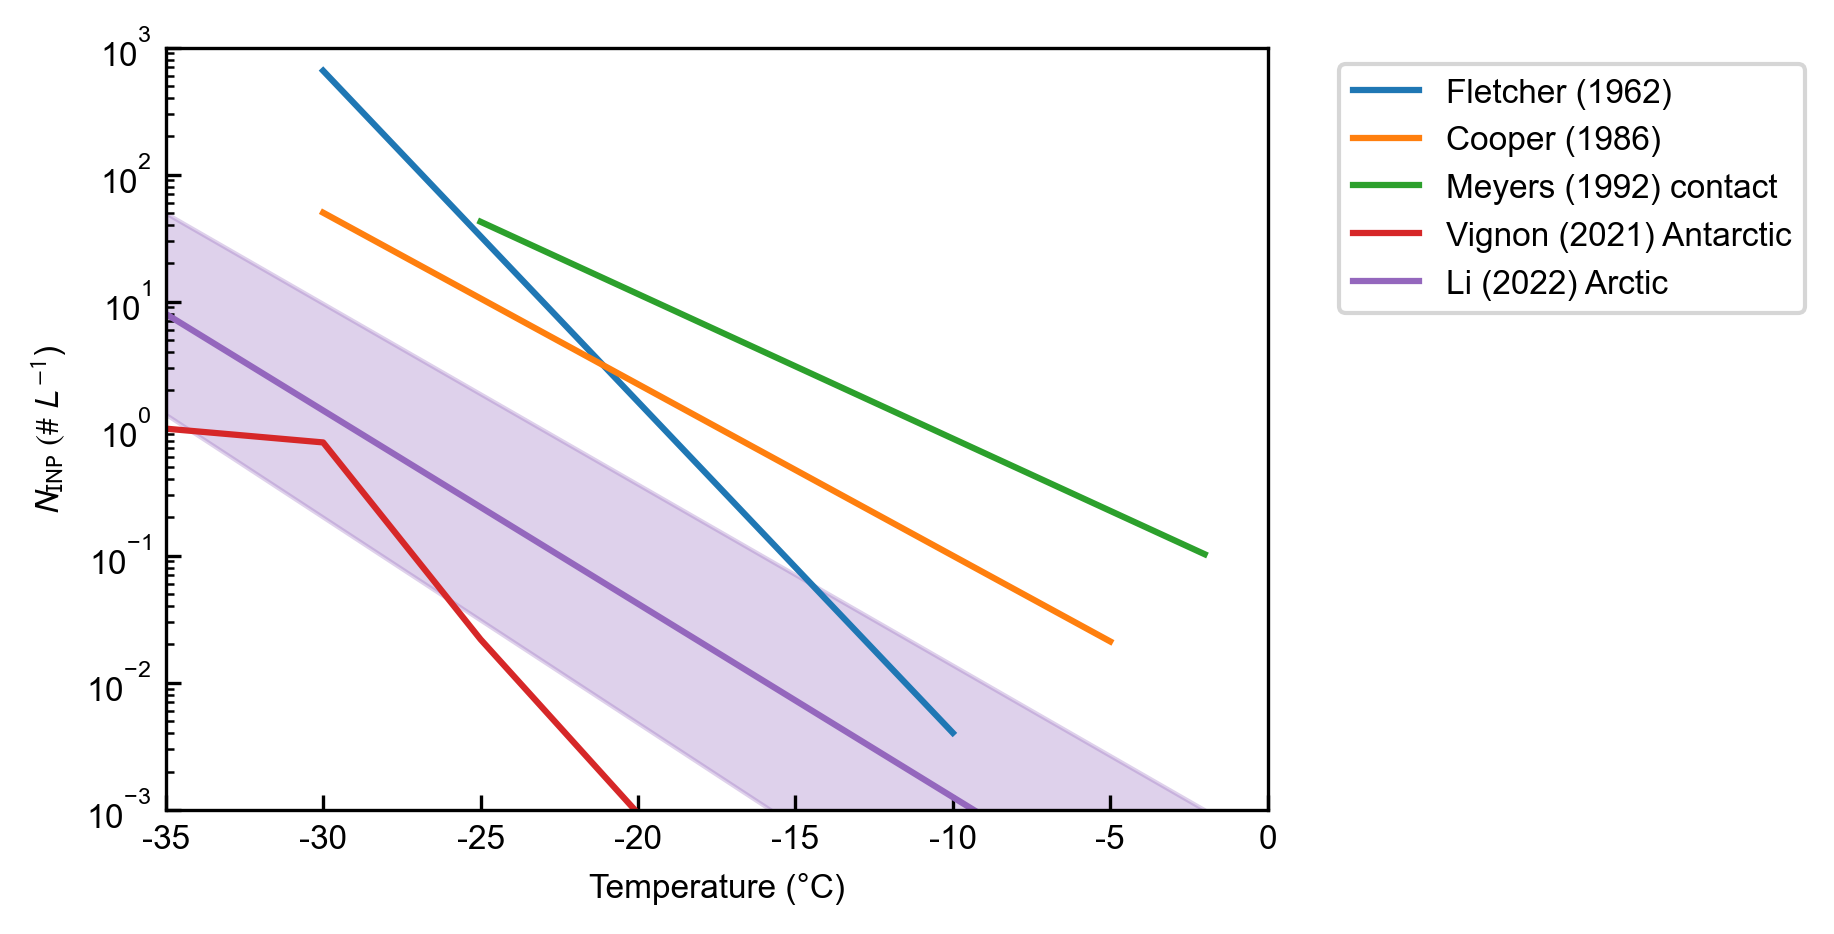

In [25]:
fig = plt.figure(figsize=(6, 3), dpi=300, constrained_layout=True) # Define the figure and specify size
gs=fig.add_gridspec(1,1) # Add a grid to the figure
ax = fig.add_subplot(gs[0, 0])
ax.plot(T_Fletcher1962, N_INP_Fletcher1962, label='Fletcher (1962)')
ax.plot(T_Cooper1986, N_INP_Cooper1986, label='Cooper (1986)')
ax.plot(T_Meyers1992_contact, N_INP_Meyers1992_contact, label='Meyers (1992) contact')
ax.plot(T_Vignon2021, N_INP_Vignon2021, label='Vignon (2021) Antarctic')
ax.plot(T_Li2022, N_INP_Li2022_median, label='Li (2022) Arctic', color = "C4")
ax.fill_between(T_Li2022, N_INP_Li2022_lower, N_INP_Li2022_upper, alpha=0.3, color= "C4")
ax.set_yscale('log')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('$N_{\mathrm{INP}}\ (\#\ L^{-1}$)')
ax.set_ylim(1e-3, 1e3)
ax.set_xlim(-35, 0)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)